In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
df = pd.read_csv("data-export (1).csv")



In [4]:
df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [5]:
df.columns = df.iloc[0]
df = df.drop(index=0).reset_index(drop=True)



In [6]:
df.columns = [
    "channel group",
    "DateHour",
    "Users",
    "Sessions",
    "Engaged Sessions",
    "Average engagement time per session",
    "Engaged sessions per user",
    "Events per session",
    "Engagement rate",
    "Event count"
]



In [7]:
df.head()

,channel group,DateHour,Users,Sessions,Engaged Sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   channel group                        3182 non-null   str  
 1   DateHour                             3182 non-null   str  
 2   Users                                3182 non-null   str  
 3   Sessions                             3182 non-null   str  
 4   Engaged Sessions                     3182 non-null   str  
 5   Average engagement time per session  3182 non-null   str  
 6   Engaged sessions per user            3182 non-null   str  
 7   Events per session                   3182 non-null   str  
 8   Engagement rate                      3182 non-null   str  
 9   Event count                          3182 non-null   str  
dtypes: str(10)
memory usage: 506.9 KB


In [9]:
df["DateHour"] = pd.to_datetime(
    df["DateHour"],
    format="%Y%m%d%H",
    errors="coerce"
)

numeric_cols = df.columns.drop(["channel group", "DateHour"])

df[numeric_cols] = df[numeric_cols].apply(
    pd.to_numeric,
    errors="coerce"
)



In [10]:
df["Hour"] = df["DateHour"].dt.hour



In [11]:
df.head()

,channel group,DateHour,Users,Sessions,Engaged Sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   channel group                        3182 non-null   str           
 1   DateHour                             3182 non-null   datetime64[us]
 2   Users                                3182 non-null   int64         
 3   Sessions                             3182 non-null   int64         
 4   Engaged Sessions                     3182 non-null   int64         
 5   Average engagement time per session  3182 non-null   float64       
 6   Engaged sessions per user            3182 non-null   float64       
 7   Events per session                   3182 non-null   float64       
 8   Engagement rate                      3182 non-null   float64       
 9   Event count                          3182 non-null   int64         
 10  Hour                   

In [13]:
df.describe()

,DateHour,Users,Sessions,Engaged Sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


sessions and user over time

In [14]:
sns.set(style="whitegrid")



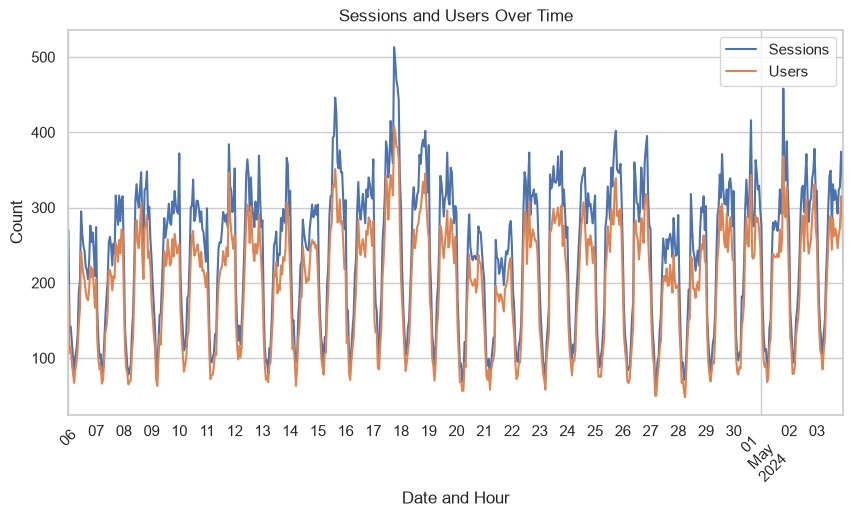

In [15]:
plt.figure(figsize=(10, 5))

df.groupby("DateHour")[["Sessions", "Users"]].sum().plot(
    ax=plt.gca()
)

plt.title("Sessions and Users Over Time")
plt.xlabel("Date and Hour")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

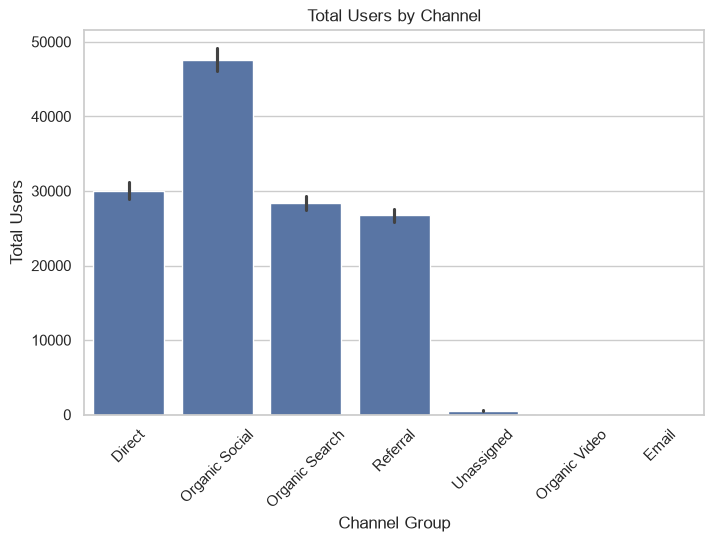

In [16]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="channel group",
    y="Users",
    estimator=np.sum
)

plt.title("Total Users by Channel")
plt.xlabel("Channel Group")
plt.ylabel("Total Users")
plt.xticks(rotation=45)

plt.show()

In [17]:
users_by_channel = (
    df.groupby("channel group")["Users"]
    .sum()
    .sort_values(ascending=False)
)

print(users_by_channel)

channel group
Organic Social    47572
Direct            30042
Organic Search    28387
Referral          26774
Unassigned          540
Organic Video       123
Email                 2
Name: Users, dtype: int64


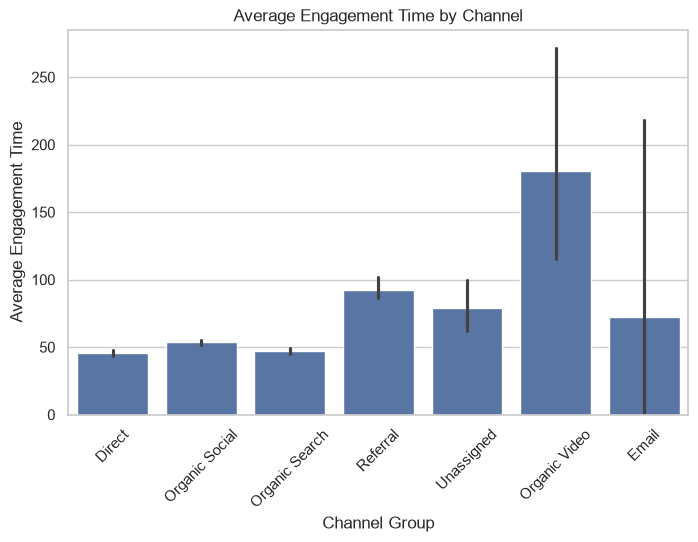

In [18]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="channel group",
    y="Average engagement time per session",
    estimator=np.mean
)

plt.title("Average Engagement Time by Channel")
plt.xlabel("Channel Group")
plt.ylabel("Average Engagement Time")
plt.xticks(rotation=45)

plt.show()

In [19]:
df.head()

,channel group,DateHour,Users,Sessions,Engaged Sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


Engagement Rate Distribution by channel

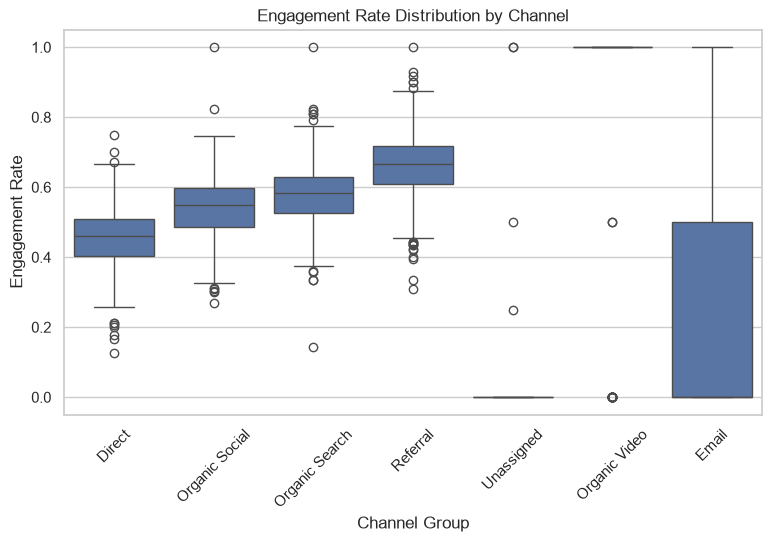

In [20]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="channel group",
    y="Engagement rate"
)

plt.title("Engagement Rate Distribution by Channel")
plt.xlabel("Channel Group")
plt.ylabel("Engagement Rate")
plt.xticks(rotation=45)

plt.show()

In [21]:
channel_engagement = (
    df.groupby("channel group")["Engagement rate"]
    .mean()
    .sort_values(ascending=False)
)

print(channel_engagement)

channel group
Organic Video     0.760000
Referral          0.660882
Organic Search    0.578906
Organic Social    0.541180
Direct            0.455723
Email             0.333333
Unassigned        0.007514
Name: Engagement rate, dtype: float64


Engaged vs Non-Engaged Sessions

In [22]:
session_df = (
    df.groupby("channel group")[["Sessions", "Engaged Sessions"]]
    .sum()
)

session_df["Non-Engaged Sessions"] = (
    session_df["Sessions"] - session_df["Engaged Sessions"]
)

session_df

,Sessions,Engaged Sessions,Non-Engaged Sessions
channel group,,,
Direct,37203,17243,19960
Email,3,1,2
Organic Search,33372,19425,13947
Organic Social,60627,32697,27930
Organic Video,141,109,32
Referral,30990,20653,10337
Unassigned,559,4,555


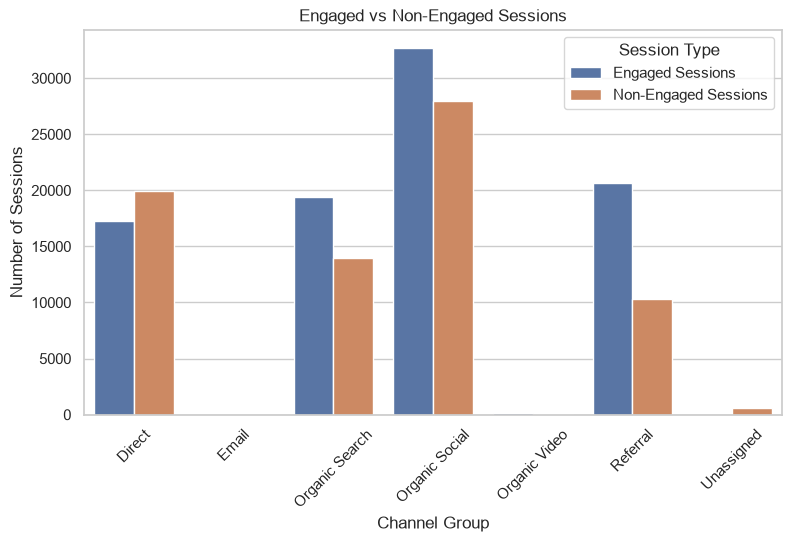

In [25]:
session_df_melted = (
    session_df
    .reset_index()
    .melt(
        id_vars="channel group",
        value_vars=[
            "Engaged Sessions",
            "Non-Engaged Sessions"
        ],
        var_name="Session Type",
        value_name="Session Count"
    )
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=session_df_melted,
    x="channel group",
    y="Session Count",
    hue="Session Type"
)

plt.title("Engaged vs Non-Engaged Sessions")
plt.xlabel("Channel Group")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=45)

plt.show()

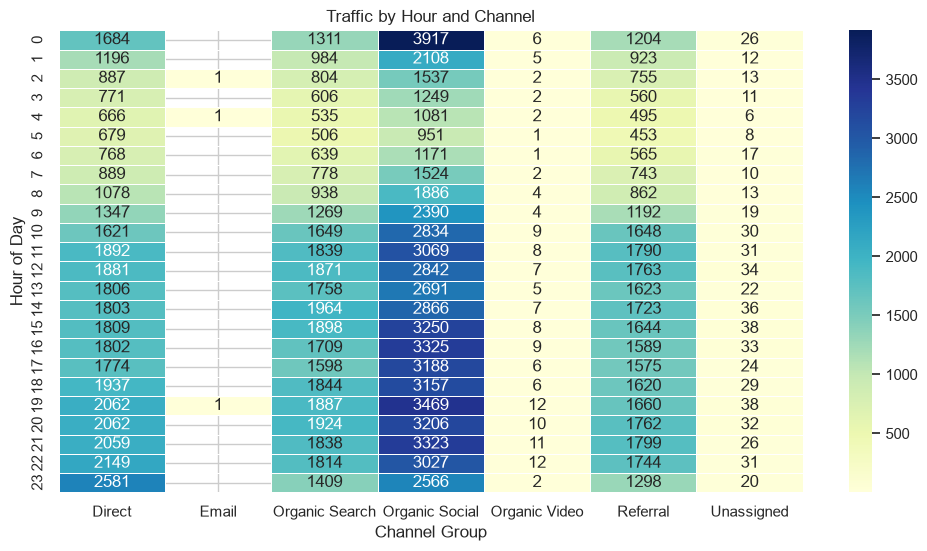

In [26]:
heatmap_data = (
    df.groupby(["Hour", "channel group"])["Sessions"]
    .sum()
    .unstack()
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    annot=True,
    fmt=".0f"
)

plt.title("Traffic by Hour and Channel")
plt.xlabel("Channel Group")
plt.ylabel("Hour of Day")

plt.show()

In [27]:
peak_hours = (
    df.groupby(["channel group", "Hour"])["Sessions"]
    .sum()
    .reset_index()
)

peak_hours = peak_hours.loc[
    peak_hours.groupby("channel group")["Sessions"].idxmax()
]

print(peak_hours)

      channel group  Hour  Sessions
23           Direct    23      2581
24            Email     2         1
41   Organic Search    14      1964
51   Organic Social     0      3917
94    Organic Video    19        12
120        Referral    21      1799
138      Unassigned    15        38


In [28]:
df_plot = (
    df.groupby("DateHour")
    .agg({
        "Sessions": "sum",
        "Engagement rate": "mean"
    })
    .reset_index()
)

df_plot.head()

,DateHour,Sessions,Engagement rate
0,2024-04-06 00:00:00,270,0.450262
1,2024-04-06 01:00:00,142,0.489905
2,2024-04-06 02:00:00,142,0.595759
3,2024-04-06 03:00:00,122,0.446725
4,2024-04-06 04:00:00,102,0.494964


In [29]:
correlation = (
    df_plot["Sessions"]
    .corr(df_plot["Engagement rate"])
)

print("Correlation:", correlation)

Correlation: -0.049140392145051295


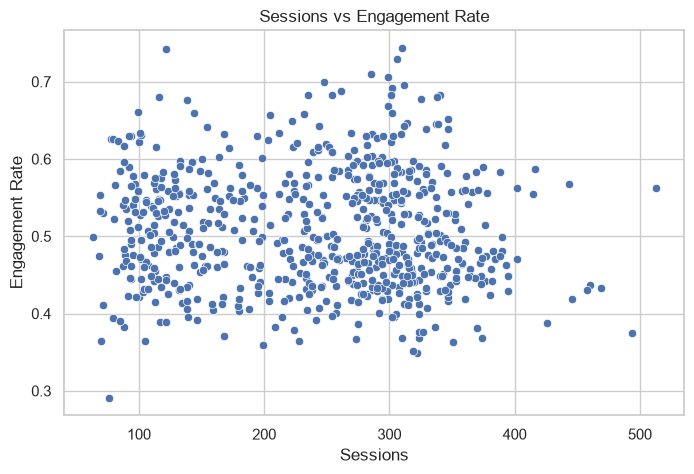

In [33]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_plot,
    x="Sessions",
    y="Engagement rate"
)

plt.title("Sessions vs Engagement Rate")
plt.xlabel("Sessions")
plt.ylabel("Engagement Rate")

plt.show()